In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

data_dir = "Logs/CSVLogger"
subdir_name = "version_"
df = []
for i in os.listdir(data_dir):
    if i.startswith(subdir_name):
        df.append(pd.read_csv(f"{data_dir}/{i}/metrics.csv"))

df = pd.concat(df, axis = 0)
df

,epoch,step,train_acc,train_loss,val_acc,val_acc_just_0,val_acc_just_1,val_loss
0,0,49,0.626667,0.701813,NaN,NaN,NaN,NaN
1,0,99,0.520000,0.771153,NaN,NaN,NaN,NaN
2,0,149,0.653333,0.661771,NaN,NaN,NaN,NaN
3,0,199,0.626667,0.670631,NaN,NaN,NaN,NaN
4,0,249,0.626667,0.687397,NaN,NaN,NaN,NaN
5,0,299,0.693333,0.654161,NaN,NaN,NaN,NaN
6,0,299,NaN,NaN,0.6488,0.504,0.496,0.673267
7,1,349,0.653333,0.640096,NaN,NaN,NaN,NaN
8,1,399,0.586667,0.665289,NaN,NaN,NaN,NaN
9,1,449,0.706667,0.648656,NaN,NaN,NaN,NaN


In [116]:
df_means = df.groupby("epoch").mean()
df_stds = df.groupby("epoch").std()

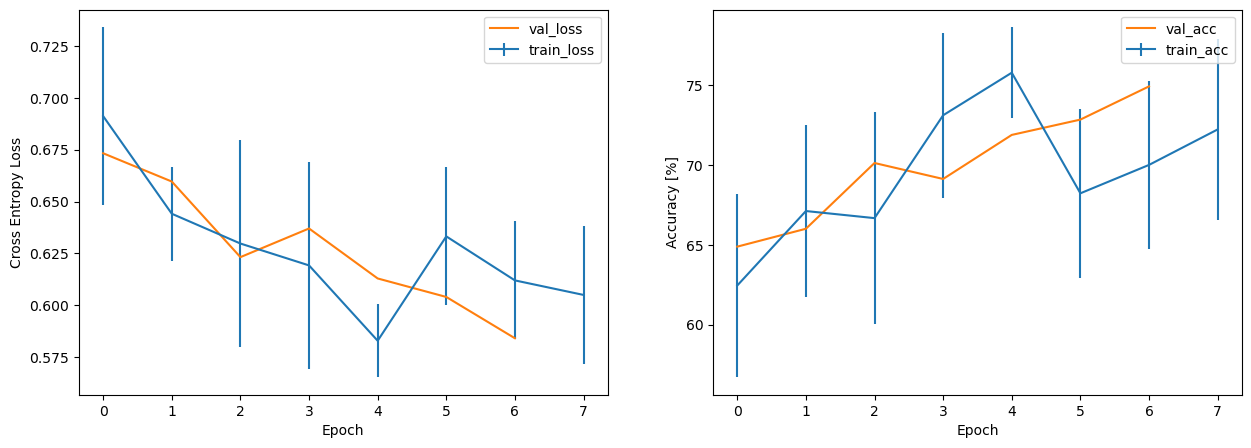

In [117]:
fig = plt.figure(figsize = (15, 5))
ax = fig.add_subplot(1, 2, 1)
ax.errorbar(x = list(df_means.index), y = df_means.train_loss, yerr = df_stds.train_loss, label = "train_loss")
ax.plot(list(df_means.index), df_means.val_loss, label = "val_loss")
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross Entropy Loss")

ax = fig.add_subplot(1, 2, 2)
ax.errorbar(x = list(df_means.index), y = df_means.train_acc*100, yerr = df_stds.train_acc*100, label = "train_acc")
ax.plot(list(df_means.index), df_means.val_acc*100, label = "val_acc")
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy [%]")

plt.show()
